In [173]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.datasets import load_iris
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans

In [174]:
iris_flowers = load_iris()
df = pd.DataFrame(iris_flowers.data, columns=iris_flowers.feature_names)
df.drop(['sepal length (cm)',	'sepal width (cm)'], axis=1, inplace=True)

In [175]:
df.head()

,petal length (cm),petal width (cm)
0,1.4,0.2
1,1.4,0.2
2,1.3,0.2
3,1.5,0.2
4,1.4,0.2


In [176]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 2 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   petal length (cm)  150 non-null    float64
 1   petal width (cm)   150 non-null    float64
dtypes: float64(2)
memory usage: 2.5 KB


In [177]:
df.isnull().sum()

,0
petal length (cm),0
petal width (cm),0


In [178]:
scaler = MinMaxScaler()
df['petal length (cm)'] = scaler.fit_transform(df[['petal length (cm)']])
df['petal width (cm)'] = scaler.fit_transform(df[['petal width (cm)']])
df.tail()

,petal length (cm),petal width (cm)
145,0.711864,0.916667
146,0.677966,0.750000
147,0.711864,0.791667
148,0.745763,0.916667
149,0.694915,0.708333


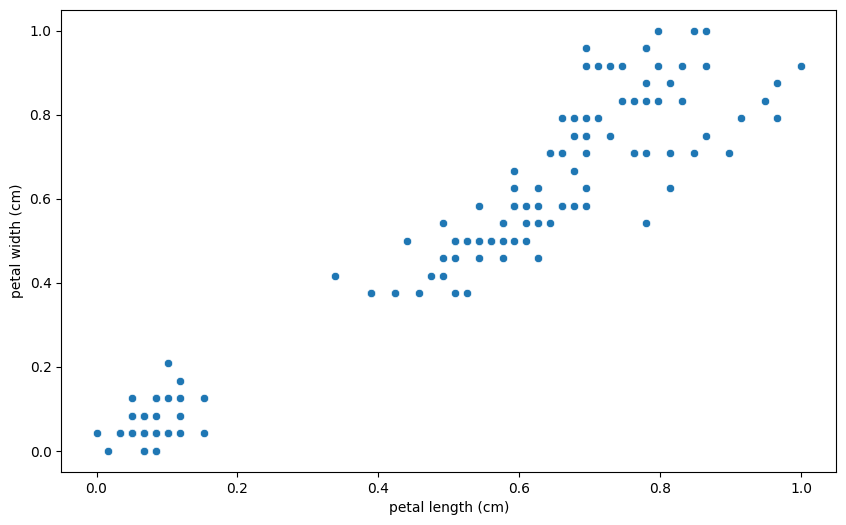

In [179]:
plt.figure(figsize=(10, 6))
sns.scatterplot(df, x='petal length (cm)', y='petal width (cm)')
plt.show()

In [180]:
km = KMeans(n_clusters=3)
prediction = km.fit_predict(df[['petal length (cm)', 'petal width (cm)']])
df['cluster'] = prediction
df.sample(6)

,petal length (cm),petal width (cm),cluster
121,0.661017,0.791667,2
123,0.661017,0.708333,2
40,0.050847,0.083333,1
111,0.728814,0.750000,2
62,0.508475,0.375000,0
129,0.813559,0.625000,2


In [181]:
km.cluster_centers_

array([[0.55867014, 0.51041667],
       [0.07830508, 0.06083333],
       [0.7740113 , 0.81510417]])

In [182]:
df1 = df[df['cluster'] == 0]
df2 = df[df['cluster'] == 1]
df3 = df[df['cluster'] == 2]

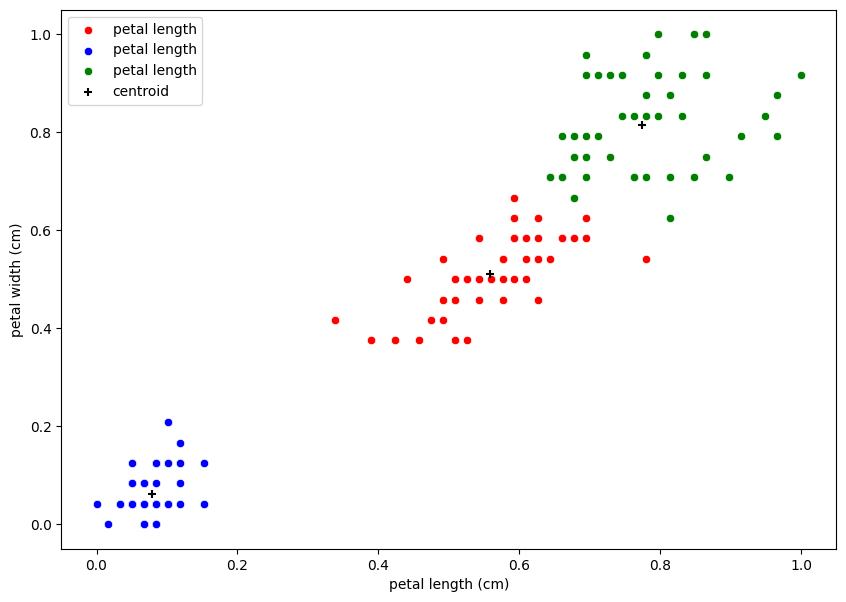

In [183]:
plt.figure(figsize=(10, 7))
sns.scatterplot(df1, x='petal length (cm)', y='petal width (cm)', color='red', label='petal length')
sns.scatterplot(df2, x='petal length (cm)', y='petal width (cm)', color='blue', label='petal length')
sns.scatterplot(df3, x='petal length (cm)', y='petal width (cm)', color='green', label='petal length')
plt.scatter(km.cluster_centers_[:, 0], km.cluster_centers_[:, 1], color='black', marker = '+', label='centroid')
plt.legend()
plt.show()

In [184]:
k_range = range(1, 11)
sse = []
for k in k_range:
  km = KMeans(n_clusters = k)
  km.fit(df[['petal length (cm)', 'petal width (cm)']])
  sse.append(km.inertia_)

In [185]:
sse

[28.36835321972719,
 5.176463590044366,
 1.701874688192097,
 1.1826653136050636,
 0.9643366270015635,
 0.6889019224531718,
 0.6685616335987293,
 0.567063043144611,
 0.4420358334556682,
 0.3638763797610482]

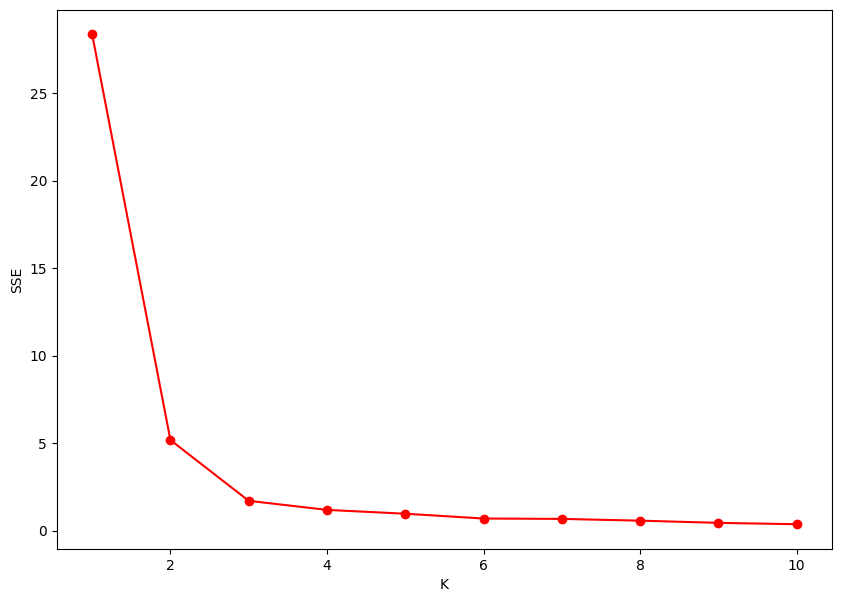

In [186]:
plt.figure(figsize=(10, 7))
plt.plot(k_range, sse, marker='o', color='red')
plt.xlabel('K')
plt.ylabel('SSE')
plt.show()